# Ganopolski 2024- Toward generalized Milankovitch theory 

In [1]:
import pandas as pd
%load_ext autoreload
%autoreload 2
from signal_models.ganopolski2024 import dVdt, calc_f, calc_df
import numpy as np
from scipy.integrate import solve_ivp
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

## Model 3
From Ganopolski et al. 2024:
`vc` = value for critical ice volume; controls the dominant periodicity and degree of asymmetry of glacial cycles
`f1` = insolation threshold for glacial inception (pinned at -20 to -15 W/m^2)
`t1` = relaxation time scale for glacial inception (in kyr)
`f2` = insolation threshold for deglaciation inception (tunable; positive)
`t2` = relaxation time scale for deglaciation (in kyr)

`A` = magnitude of forcing in Wm−2
`eps` = nondimensional magnitude of amplitude modulation


In [2]:
k_init = 1 # Initial k; glacial state
v_init = 1  # Initial ice volume
initial_conditions = [v_init, k_init]  # Initial v and k

The code works with: 

t = time in kyr
v = ice volume (nondimensional)
k = state of the system (1 = glacial, 2 = deglaciation)

Within the code, k is calulated according to:

- transition from a glacial (k=1) to deglaciation regime (k = 2) occurs if three conditions are met:
    - v > vc, 
    - dfdt > 0, 
    - f > 0.
        
- The transition from deglaciation (k=2) to glacial (k=1) regime occurs if:
    - f < glaciation threshold f1.
The interglacial state formally belongs to the deglaciation regime.

In [133]:
tn = 1000
t0 = 0
sampling_res =2
t_span = (t0, tn)
t_eval = np.arange(t0, tn, sampling_res)

In [119]:
A = 25
eps = 0.5
f1 = -16
f2 = 16
vc = 1.4
t1 = 30
t2 = 100
vi = 0

In [7]:
solution_rk45 = solve_ivp(
    dVdt,
    t_span,
    initial_conditions,
    dense_output=True,
    method='RK45',  # 'LSODA' is the default method for solve_ivp
    # t_eval=t_eval, 
    max_step=sampling_res, atol = 10, rtol = 10,
    min_step=sampling_res,
    args=(A, eps, f1, f2, t2, t1, vc),
)

/Users/jlanders/miniconda3/envs/pb_env/lib/python3.12/site-packages/scipy/integrate/_ivp/ivp.py:621: UserWarning: The following arguments have no effect for a chosen solver: `min_step`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)
/Users/jlanders/PycharmProjects/PaleoBeasts/signal_models/ganopolski2024.py:52: RuntimeWarning: invalid value encountered in sqrt
  return 1 + np.sqrt((f2 - f) / (f2 - f1))
/Users/jlanders/PycharmProjects/PaleoBeasts/signal_models/ganopolski2024.py:58: RuntimeWarning: invalid value encountered in sqrt
  return 1 - np.sqrt((f2 - f) / (f2 - f1))


In [8]:
from scipy.integrate import ode
solution_LSODA = solve_ivp(
    dVdt,
    t_span,
    initial_conditions,
    dense_output=True,
    method='LSODA',  # 'LSODA' is the default method for solve_ivp
    # t_eval=t_eval, 
    args=(A, eps, f1, f2, t2, t1, vc),
)

In [155]:
start_kya = tn
length = tn
end_kya = start_kya-length

Text(0.5, 0, 'time (kyr)')

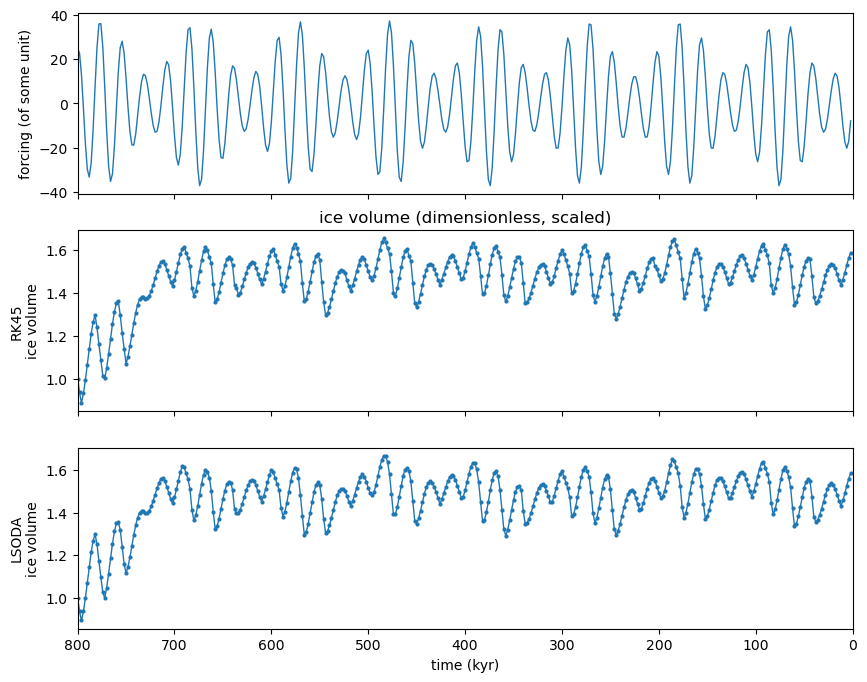

In [9]:
start_kya = tn
length = tn
end_kya = start_kya-length

t_range = np.arange(max(solution_rk45.t)-start_kya, max(solution_rk45.t)-end_kya, sampling_res)

ice_vol_lsoda = solution_LSODA.sol(t_range)[0].reshape(-1, 1)
# ice_vol_lsoda[ice_vol_lsoda < 0] = 0
# ice_vol_lsoda = MinMaxScaler().fit_transform(ice_vol_lsoda)#, feature_range=(0, 1.5))

ice_vol_rk45 = solution_rk45.sol(t_range)[0].reshape(-1, 1)
# ice_vol_rk45[ice_vol_rk45 < 0] = 0
# ice_vol_ss = MinMaxScaler().fit_transform(ice_vol)#,  feature_range=(0, 1.5))

forcing = calc_f(t_range, A, eps)
# forcing = solution_rk45.sol(t_range)[1].reshape(-1, 1)


ticks = np.linspace(max(solution_rk45.t)-start_kya, max(solution_rk45.t)-end_kya, 9)  # Generate 6 ticks from 800 to 3000
tick_labels = [str(int(max(solution_rk45.t) - tick)) for tick in ticks]  # Calculate labels 800 to 0


fig, ax = plt.subplots(3, 1, sharex=True, figsize=(10, 8))
ax[0].plot(t_range, forcing, linewidth=1)
ax[0].set_ylabel('forcing (of some unit)')

ax[1].set_title('ice volume (dimensionless, scaled)')
ax[1].plot(t_range, ice_vol_rk45, linewidth=1, marker='o', markersize=2, label='RK45')
# ax[1].plot(t_range, ice_vol_lsoda, linewidth=1, marker='o', markersize=2, label='LSODA')
ax[1].set_xticks(ticks)
ax[1].set_xticklabels(tick_labels)
ax[1].set_ylabel('\n'.join(['RK45','ice volume']))
ax[1].set_xlim([max(solution_rk45.t)-start_kya, max(solution_rk45.t)-end_kya])

# ax[1].set_xlabel('time (kyr)')
# ax[1].legend()

ax[2].plot(t_range, ice_vol_lsoda, linewidth=1, marker='o', markersize=2)
ax[2].set_xticks(ticks)
ax[2].set_ylabel('\n'.join(['LSODA','ice volume']))
ax[2].set_xlim([max(solution_rk45.t)-start_kya, max(solution_rk45.t)-end_kya])

ax[-1].set_xticklabels(tick_labels)
ax[-1].set_xlabel('time (kyr)')

Text(0.5, 0, 'time (kyr)')

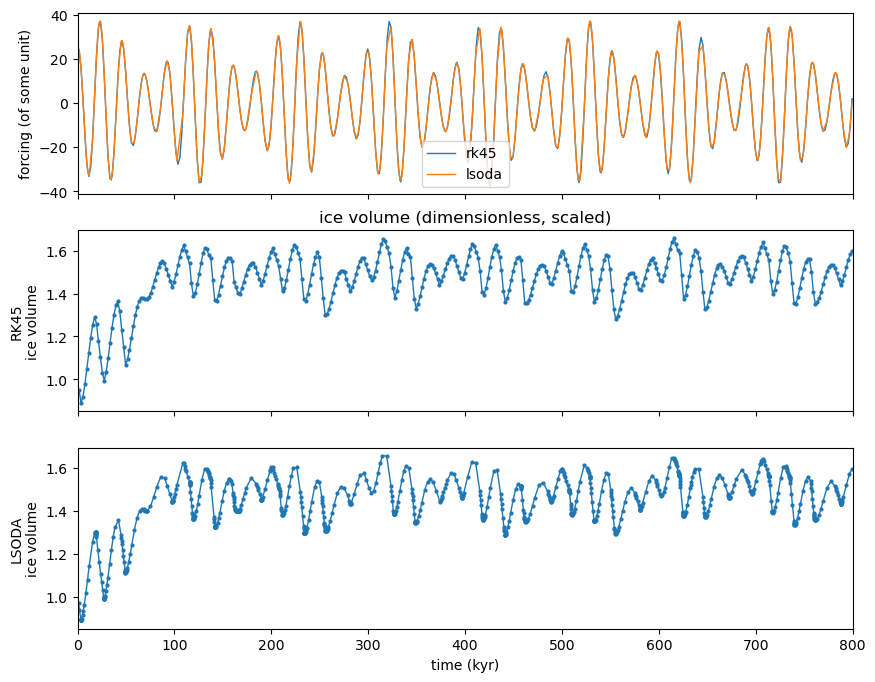

In [10]:

# t_range = solution_rk45.t#np.arange(max(solution.t)-800, max(solution.t), 4)

ticks = np.linspace(max(solution_rk45.t)-start_kya, max(solution_rk45.t)-end_kya, 9)  # Generate 6 ticks from 800 to 3000
tick_labels = [str(int(max(solution_rk45.t) - tick)) for tick in ticks]  # Calculate labels 800 to 0

mask_rk45 = (solution_rk45.t > max(solution_rk45.t)-start_kya) & (solution_rk45.t < max(solution_rk45.t)-end_kya)# mask_rk45 = solution_rk45.t[mask_rk45] < max(solution_rk45.t)-end_kya
time_rk45 = solution_rk45.t[mask_rk45]
ice_vol_rk45 = solution_rk45.y[0][mask_rk45]
forcing_rk45 = calc_f(time_rk45, A, eps)
# forcing = solution_rk45.y[1][mask_rk45]


mask_lsoda = (solution_LSODA.t > max(solution_LSODA.t)-start_kya) & (solution_LSODA.t < max(solution_LSODA.t)-end_kya)# mask_rk45 = solution_rk45.t[mask_rk45] < 
ice_vol_lsoda = solution_LSODA.y[0][mask_lsoda]
time_lsoda = solution_LSODA.t[mask_lsoda]
forcing_lsoda = calc_f(time_lsoda, A, eps)



fig, ax = plt.subplots(3, 1, sharex=True, figsize=(10, 8))
ax[0].plot(time_rk45, forcing_rk45, linewidth=1, label='rk45')
ax[0].plot(time_lsoda, forcing_lsoda, linewidth=1, label='lsoda')

ax[0].set_ylabel('forcing (of some unit)')
ax[0].legend()

ax[1].set_title('ice volume (dimensionless, scaled)')
ax[1].plot(time_rk45, ice_vol_rk45, linewidth=1, marker='o', markersize=2, label='RK45')
# ax[1].plot(t_range, ice_vol_lsoda, linewidth=1, marker='o', markersize=2, label='LSODA')
ax[1].set_xticks(ticks)
# ax[1].set_xticklabels(tick_labels)
ax[1].set_ylabel('\n'.join(['RK45','ice volume']))
ax[1].set_xlim([max(solution_rk45.t)-start_kya, max(solution_rk45.t)-end_kya])

ax[2].plot(time_lsoda, ice_vol_lsoda, linewidth=1, marker='o', markersize=2)
ax[2].set_xticks(ticks)
ax[2].set_ylabel('\n'.join(['LSODA','ice volume']))
ax[2].set_xlim([max(solution_rk45.t)-start_kya, max(solution_rk45.t)-end_kya])

# ax[-1].set_xticklabels(tick_labels)
ax[-1].set_xlabel('time (kyr)')

# Class

In [157]:
from signal_models.g24 import Model3, calc_df, calc_f
from signal_models.forcing import Forcing
from signal_models.solver_util import Solver


In [158]:
g24_forcing = Forcing(calc_f, derivative=calc_df)

In [223]:
A = 25
eps = 0.5
f1 = -16
f2 = 16
vc = 1.47
t1 = 30
t2 = 10
vi = 0

In [224]:
model3 = Model3(forcing=g24_forcing, var_name='ice volume', vc=vc, f1=f1, f2=f2, t1=t1, t2=t2)
v_init= 0
k_init = 1

In [243]:
length = 1300
t0 = 0
tend = t0+length
delta_t=4

In [244]:

model3.k_arr = [k_init]
model3.t_arr = [0]
model3_rk45 = Solver(model3, t_span=(t0, tend), y0=[v_init, k_init], kwargs={'atol': .5, 'rtol': .5, 'max_step':delta_t})
model3_rk45.define_t_eval(delta_t=delta_t)
model3_rk45.integrate()#kwargs={'atol': .5, 'rtol': .5, 'max_step':delta_t})

tmp_df = pd.DataFrame({'t':np.array(model3.t_arr), 'k':np.array(model3.k_arr)})
tmp_df.drop_duplicates(subset='t', inplace=True)
model3_rk45.diagnostics['k_arr'] = np.array(tmp_df['k'])
model3_rk45.diagnostics['t_arr'] = np.array(tmp_df['t'])

# #kwargs={'atol': .5, 'rtol': .5, 'max_step':delta_t})

/Users/jlanders/PycharmProjects/PaleoBeasts/signal_models/g24.py:96: RuntimeWarning: invalid value encountered in sqrt
  def calc_vu(self, f):
/Users/jlanders/PycharmProjects/PaleoBeasts/signal_models/g24.py:102: RuntimeWarning: invalid value encountered in sqrt
  def calc_vc(self, t):


In [245]:
model3.k_arr = [k_init]
model3.t_arr = [0]
model3_lsoda = Solver(model3, t_span=(t0, tend), y0=[v_init, k_init], method='LSODA')
model3_lsoda.integrate()
model3_lsoda.diagnostics['k_arr'] = np.array(model3.k_arr)
model3_lsoda.diagnostics['t_arr'] = np.array(model3.t_arr)


/Users/jlanders/PycharmProjects/PaleoBeasts/signal_models/g24.py:96: RuntimeWarning: invalid value encountered in sqrt
  def calc_vu(self, f):
/Users/jlanders/PycharmProjects/PaleoBeasts/signal_models/g24.py:102: RuntimeWarning: invalid value encountered in sqrt
  def calc_vc(self, t):


In [251]:
import pandas as pd
model3.k_arr = [k_init]
model3.t_arr = [0]

model3_euler = Solver(model3, method='euler', t_span=(t0, tend), y0=[v_init, k_init], kwargs={'state_param': False, 'dt':delta_t})
model3_euler.integrate()
tmp_df = pd.DataFrame({'t':np.array(model3.t_arr), 'k':np.array(model3.k_arr)})
tmp_df.drop_duplicates(subset='t', inplace=True)

model3_euler.diagnostics['k_arr'] = np.array(tmp_df['k'])
model3_euler.diagnostics['t_arr'] = np.array(tmp_df['t'])


/Users/jlanders/PycharmProjects/PaleoBeasts/signal_models/g24.py:96: RuntimeWarning: invalid value encountered in sqrt
  def calc_vu(self, f):
/Users/jlanders/PycharmProjects/PaleoBeasts/signal_models/g24.py:102: RuntimeWarning: invalid value encountered in sqrt
  def calc_vc(self, t):


In [223]:
A = 25
eps = 0.5
f1 = -16
f2 = 16
vc = 1.47
t1 = 30
t2 = 10
vi = 0

In [325]:
model3 = Model3(forcing=g24_forcing, var_name='ice volume', vc=vc, f1=f1, f2=f2, t1=t1, t2=t2)
v_init= 0
k_init = 1

In [352]:
length = 1200
t0 = 0
tend = t0+length
delta_t=6.5

In [356]:
model3_euler = Solver(model3, method='euler', t_span=(t0, tend), y0=[v_init, k_init], kwargs={'state_param': False, 'dt':delta_t})
model3_lsoda = Solver(model3, t_span=(t0, tend), y0=[v_init, k_init], method='LSODA')
model3_rk45 = Solver(model3, t_span=(t0, tend), y0=[v_init, k_init], kwargs={'atol': .2, 'rtol': .2, 'max_step':delta_t})

for model in [model3_euler, model3_lsoda, model3_rk45]:
    model.model.k_arr = [k_init]
    model.model.t_arr = [0]
    model.integrate()
    tmp_df = pd.DataFrame({'t':np.array(model3.t_arr), 'k':np.array(model3.k_arr)})
    tmp_df.drop_duplicates(subset='t', inplace=True)
    model.diagnostics['k_arr'] = np.array(tmp_df['k'])
    model.diagnostics['t_arr'] = np.array(tmp_df['t'])




/Users/jlanders/PycharmProjects/PaleoBeasts/signal_models/g24.py:90: RuntimeWarning: invalid value encountered in sqrt
  def calc_vg(self, f):
/Users/jlanders/PycharmProjects/PaleoBeasts/signal_models/g24.py:96: RuntimeWarning: invalid value encountered in sqrt
  def calc_vu(self, f):


Text(0.5, 0, 'time (kyr)')

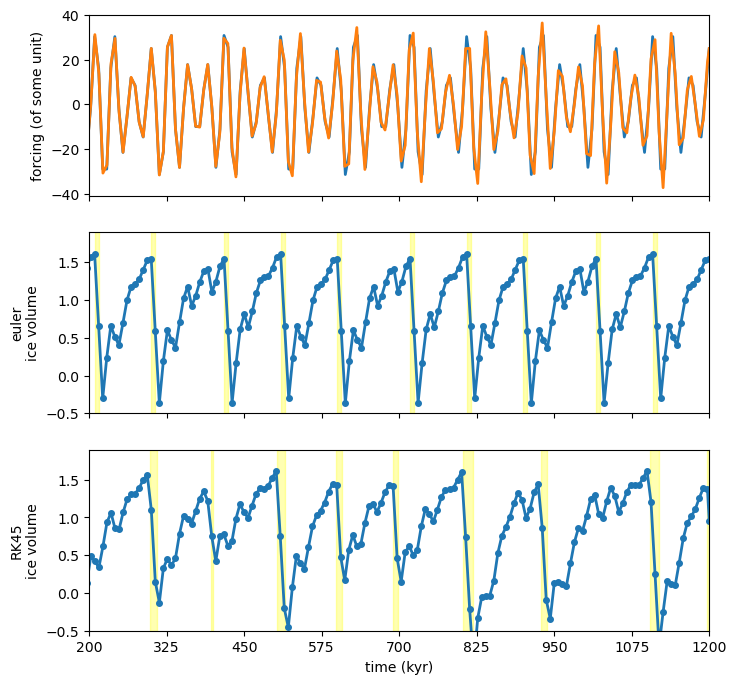

In [360]:
start_kya=1000
end_kya=0

# model3_lsoda
model_sols = [model3_euler,model3_rk45]
smooth = False
solver_choice = True

sampling_res=delta_t
# t_range = np.arange(max(model_sols[0].solution.t)-start_kya, max(model_sols[0].solution.t)-end_kya, sampling_res)
# ticks = np.linspace(max(model_sols[0].solution.t)-start_kya, max(model_sols[0].solution.t)-end_kya, 9)  # Generate 6 ticks from 800 to 3000
# tick_labels = [str(int(max(t_range) - tick)) for tick in ticks]  # Calculate labels 800 to 0

t_range = np.arange(max(model_sols[0].solution.t)-start_kya, max(model_sols[0].solution.t)-end_kya, sampling_res)
ticks = np.linspace(max(model_sols[0].solution.t)-start_kya, max(model_sols[0].solution.t)-end_kya, 9)  # Generate 6 ticks from 800 to 3000
tick_labels = [str(int(tick)) for tick in ticks]  # Calculate labels 800 to 0

fig, ax = plt.subplots(len(model_sols)+1, 1, sharex=True, figsize=(8, 8))

for ik, model_sol in enumerate(model_sols):
    is_2 = np.array(model_sol.diagnostics['k_arr']) == 2
    t_arr = model_sol.diagnostics['t_arr']
    k_arr = model_sol.diagnostics['k_arr']
    
    df = pd.DataFrame({'Time': t_arr, 'k': k_arr})
    df.sort_values('Time', inplace=True)
    df = df[df['Time']>min(t_range)]

    # Identify where 'k' changes
    df['shifted_k'] = df['k'].shift(-1)  # Shift k values down for comparison
    # Start of intervals
    df['start'] = (df['k'] == 2) & (df['k'].shift(1) != 2)
    # End of intervals (note the last interval needs special handling)
    df['end'] = (df['k'] == 2) & (df['shifted_k'] != 2)
    
    
    # Extract intervals
    intervals = []
    for _, row in df.iterrows():
        if row['start']:
            start_time = row['Time']
        if row['end']:
            end_time = row['Time']
            intervals.append((start_time, end_time))
    
    # Handling case where last interval does not end within the data range
    if df.iloc[-1]['k'] == 2 and not df.iloc[-1]['end']:
        intervals.append((start_time, df.iloc[-1]['Time']))
    
    if smooth == True:
        time = t_range

        model_sol_y = model_sol.solution.sol(time)[0].reshape(-1, 1)
        model_forcing = model_sol.model.forcing.get_forcing(time)
        label=','.join([model_sol.method, 'resampled'])
        ax[ik+1].plot(time, model_sol_y, linewidth=1, marker='o', markersize=2, label=label)
        
        if len(intervals)>0:
            for interval in intervals:
                ax[ik+1].axvspan(interval[0], interval[1], color='yellow', alpha=0.3)
                
        ax[0].plot(time, model_forcing, linewidth=2, label=label)
        
    if solver_choice ==True:
        time = model_sol.solution.t

        model_sol_y = model_sol.solution.y[0]
        model_forcing = model_sol.model.forcing.get_forcing(time)
        label=','.join([model_sol.method, 'solver sampled'])
        ax[ik+1].plot(time, model_sol_y, linewidth=2, marker='o', markersize=4, label=label)
            
        if len(intervals)>0:
            for interval in intervals:
                ax[ik+1].axvspan(interval[0], interval[1], color='yellow', alpha=0.3)
        ax[ik+1].set_xlim([max(model_sol.solution.t)-start_kya, max(model_sol.solution.t)-end_kya])
        
        ax[0].plot(time, model_forcing, linewidth=2, label=label)
        # ax[0].plot(time, calc_f(time), linewidth=2, label=label)
    
    ax[0].set_ylabel('forcing (of some unit)')
    ax[ik+1].set_xticks(ticks)
    ax[ik+1].set_ylim([-.5,1.9])
    ax[ik+1].set_ylabel('\n'.join([model_sol.method,model_sol.model.variable_name]))
    
ax[-1].set_xticklabels(tick_labels)
ax[-1].set_xlabel('time (kyr)')


In [258]:
df

,Time,k,shifted_k,start,end
2,0.209885,1,1.0,False,False
3,0.314828,1,1.0,False,False
4,0.839540,1,1.0,False,False
5,0.932822,1,1.0,False,False
1,0.948683,1,1.0,False,False
...,...,...,...,...,...
1627,1297.639540,1,1.0,False,False
1628,1297.934598,1,1.0,False,False
1629,1299.409885,1,1.0,False,False
1630,1299.672158,1,1.0,False,False
